# Notebook 05: Model Interpretability

**Runs on:** Local machine (no GPU needed)

**Prerequisites:** Model weights from Notebook 02 in `experiments/results/models/`

This notebook generates interpretability visualizations:
1. **Grad-CAM** - Which spatial regions does the model focus on?
2. **t-SNE** - How well does the model separate classes in feature space?
3. **UMAP** - Alternative embedding visualization

In [1]:
# Install interpretability packages if needed
!pip install -q pytorch-grad-cam umap-learn

zsh:1: command not found: pip


In [2]:
import os, warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import EuroSAT
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from collections import Counter
import timm

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cpu')

DATA_DIR = os.path.join(os.path.dirname(os.getcwd()), 'data')
RESULTS_DIR = os.path.join(os.path.dirname(os.getcwd()), 'experiments', 'results')
FIGURES_DIR = os.path.join(RESULTS_DIR, 'figures')
MODELS_DIR = os.path.join(RESULTS_DIR, 'models')
os.makedirs(FIGURES_DIR, exist_ok=True)

In [3]:
# Load dataset and test split
raw_dataset = EuroSAT(root=DATA_DIR, download=True)
CLASS_NAMES = ['AnnualCrop','Forest','HerbaceousVegetation','Highway','Industrial',
               'Pasture','PermanentCrop','Residential','River','SeaLake']
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

all_indices = list(range(len(raw_dataset)))
all_labels = [raw_dataset[i][1] for i in all_indices]
train_idx, temp_idx, _, temp_labels = train_test_split(
    all_indices, all_labels, test_size=0.30, random_state=SEED, stratify=all_labels)
_, test_idx, _, _ = train_test_split(
    temp_idx, temp_labels, test_size=0.50, random_state=SEED, stratify=temp_labels)

class EuroSATSubset(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, transform=None):
        self.dataset, self.indices, self.transform = dataset, indices, transform
    def __len__(self): return len(self.indices)
    def __getitem__(self, idx):
        img, label = self.dataset[self.indices[idx]]
        if self.transform: img = self.transform(img)
        return img, label

eval_transform = transforms.Compose([
    transforms.Resize((64, 64)), transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
test_dataset = EuroSATSubset(raw_dataset, test_idx, eval_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)
print(f"Test set: {len(test_idx)} images")

Test set: 4050 images


In [4]:
# Model architecture definitions
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        self.excitation = nn.Sequential(
            nn.Linear(channels, channels//reduction, bias=False), nn.ReLU(True),
            nn.Linear(channels//reduction, channels, bias=False), nn.Sigmoid())
    def forward(self, x):
        b, c = x.size()[:2]
        return x * self.excitation(self.squeeze(x).view(b, c)).view(b, c, 1, 1).expand_as(x)

class ResNetSE(nn.Module):
    def __init__(self, num_classes=10, pretrained=False, use_se=True):
        super().__init__()
        self.use_se = use_se
        self.backbone = timm.create_model('resnet50', pretrained=pretrained, num_classes=0)
        if use_se: self.se_block = SEBlock(2048, 16)
        self.classifier = nn.Sequential(
            nn.Dropout(0.3), nn.Linear(2048, 512), nn.ReLU(True),
            nn.Dropout(0.2), nn.Linear(512, num_classes))
    def forward(self, x):
        f = self.backbone.forward_features(x)
        if self.use_se: f = self.se_block(f)
        return self.classifier(F.adaptive_avg_pool2d(f, 1).flatten(1))

# Load ResNet-50+SE weights
model_path = os.path.join(MODELS_DIR, 'ResNet50_SE.pth')
model = ResNetSE(pretrained=False, use_se=True)
model.load_state_dict(torch.load(model_path, map_location='cpu', weights_only=True))
model.eval()
print(f"Loaded ResNet-50+SE from {model_path}")

Loaded ResNet-50+SE from /Users/rhythmjain/Desktop/Satellite-Based-Precision-Agriculture/Phase2_DL/experiments/results/models/ResNet50_SE.pth


## 1. Grad-CAM Visualization

**Grad-CAM** (Selvaraju et al., 2017) visualizes which spatial regions the model attends to.

Formula: L_Grad-CAM = ReLU( sum_k( alpha_k * A_k ) )

where alpha_k = (1/Z) * sum_ij( dY_c / dA_k_ij ) (global avg of gradients per feature map)

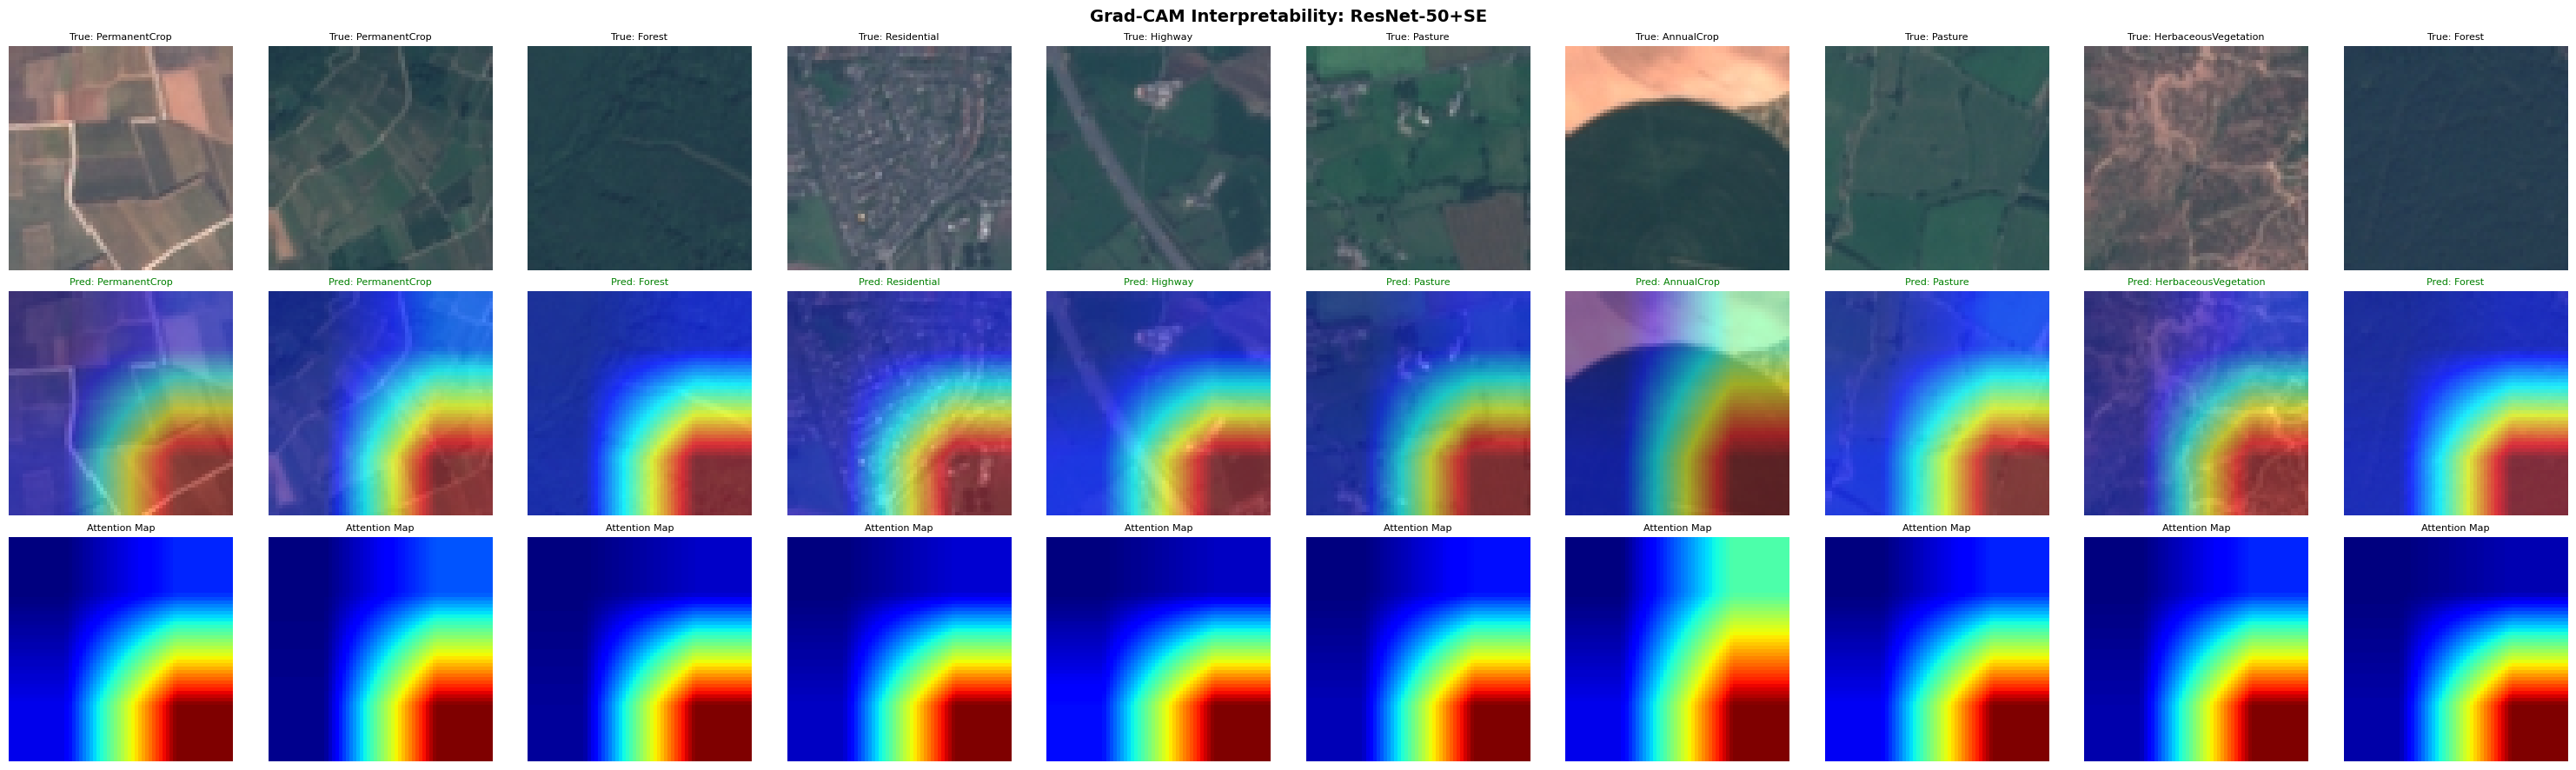

In [5]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Target: last conv layer of ResNet backbone
target_layer = model.backbone.layer4[-1]
cam = GradCAM(model=model, target_layers=[target_layer])

# Generate Grad-CAM for 10 diverse samples
n_samples = 10
fig, axes = plt.subplots(3, n_samples, figsize=(n_samples * 3, 9))

for i in range(n_samples):
    idx = i * (len(test_dataset) // n_samples)
    img_tensor, label = test_dataset[idx]
    input_tensor = img_tensor.unsqueeze(0)

    # Grad-CAM
    targets = [ClassifierOutputTarget(label)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    # Denormalize for display
    img_display = img_tensor.clone()
    for c in range(3):
        img_display[c] = img_display[c] * IMAGENET_STD[c] + IMAGENET_MEAN[c]
    img_np = img_display.clamp(0, 1).permute(1, 2, 0).numpy()
    cam_image = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    # Model prediction
    with torch.no_grad():
        pred = model(input_tensor).argmax(1).item()

    # Plot
    axes[0][i].imshow(img_np)
    axes[0][i].set_title(f'True: {CLASS_NAMES[label]}', fontsize=8)
    axes[0][i].axis('off')

    axes[1][i].imshow(cam_image)
    axes[1][i].set_title(f'Pred: {CLASS_NAMES[pred]}', fontsize=8,
                         color='green' if pred == label else 'red')
    axes[1][i].axis('off')

    axes[2][i].imshow(grayscale_cam, cmap='jet')
    axes[2][i].set_title('Attention Map', fontsize=8)
    axes[2][i].axis('off')

axes[0][0].set_ylabel('Original', fontsize=11, rotation=0, labelpad=55)
axes[1][0].set_ylabel('Grad-CAM', fontsize=11, rotation=0, labelpad=55)
axes[2][0].set_ylabel('Heatmap', fontsize=11, rotation=0, labelpad=55)

plt.suptitle('Grad-CAM Interpretability: ResNet-50+SE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'gradcam_resnet50_se.png'), dpi=150, bbox_inches='tight')
plt.show()

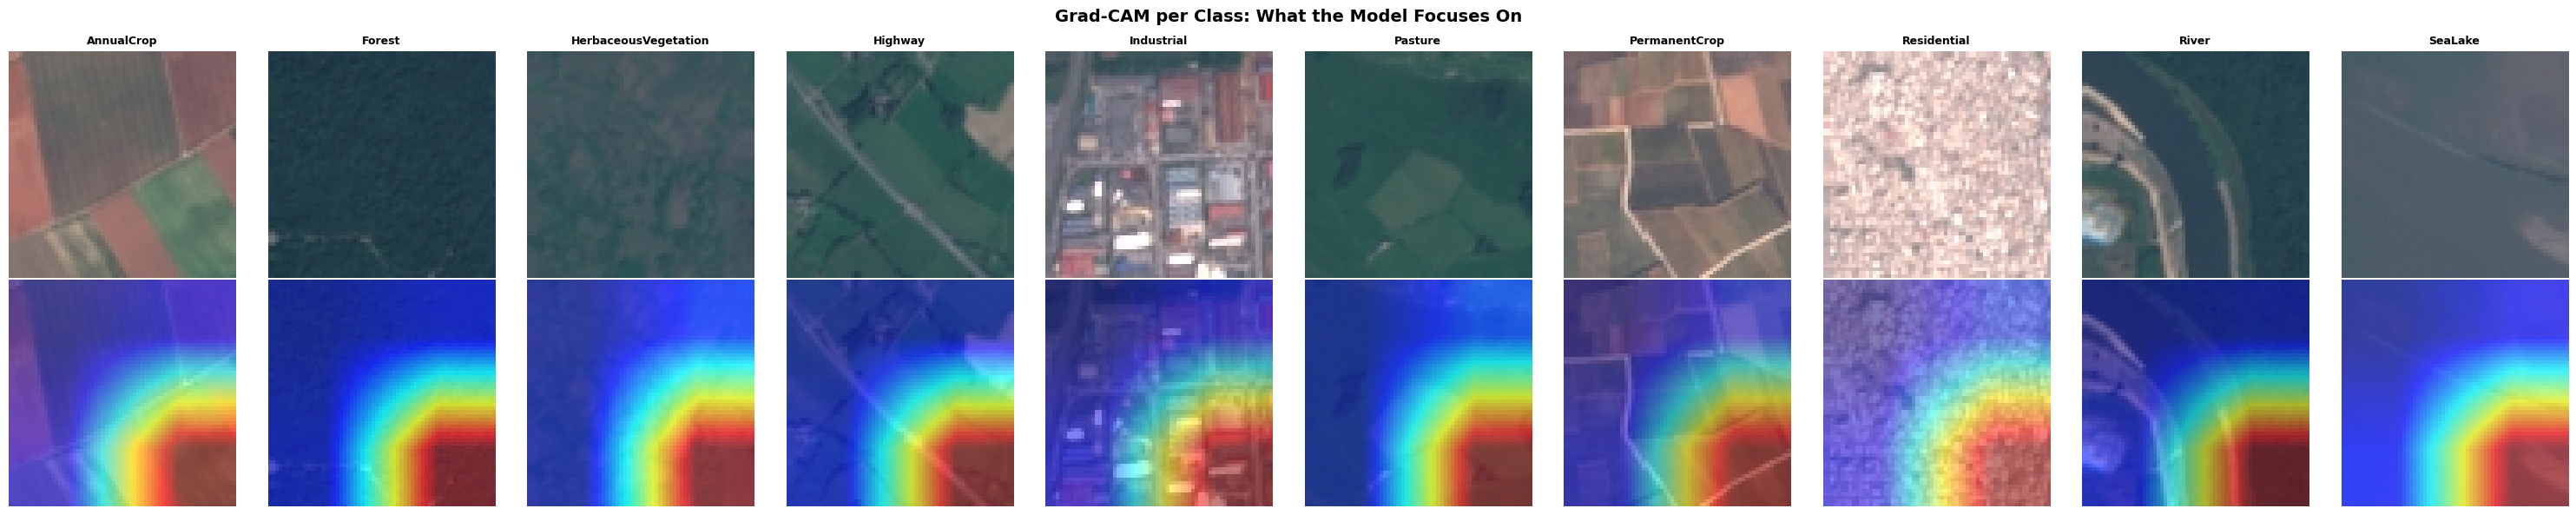

In [6]:
# Grad-CAM per class (one sample per class)
fig, axes = plt.subplots(2, len(CLASS_NAMES), figsize=(30, 6))

# Find one sample per class in test set
class_found = {}
for i in range(len(test_dataset)):
    _, label = test_dataset[i]
    if label not in class_found:
        class_found[label] = i
    if len(class_found) == len(CLASS_NAMES):
        break

for cls_idx in range(len(CLASS_NAMES)):
    sample_idx = class_found[cls_idx]
    img_tensor, label = test_dataset[sample_idx]
    input_tensor = img_tensor.unsqueeze(0)

    grayscale_cam = cam(input_tensor=input_tensor,
                        targets=[ClassifierOutputTarget(label)])[0]

    img_display = img_tensor.clone()
    for c in range(3):
        img_display[c] = img_display[c] * IMAGENET_STD[c] + IMAGENET_MEAN[c]
    img_np = img_display.clamp(0, 1).permute(1, 2, 0).numpy()
    cam_image = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    axes[0][cls_idx].imshow(img_np)
    axes[0][cls_idx].set_title(CLASS_NAMES[cls_idx], fontsize=9, fontweight='bold')
    axes[0][cls_idx].axis('off')

    axes[1][cls_idx].imshow(cam_image)
    axes[1][cls_idx].axis('off')

axes[0][0].set_ylabel('Image', fontsize=11, rotation=0, labelpad=40)
axes[1][0].set_ylabel('Grad-CAM', fontsize=11, rotation=0, labelpad=40)

plt.suptitle('Grad-CAM per Class: What the Model Focuses On', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'gradcam_per_class.png'), dpi=150, bbox_inches='tight')
plt.show()

## 2. t-SNE Embedding Visualization

Reduce the penultimate layer embeddings (2048-d) to 2D to visualize how well the model separates classes in its learned feature space.

In [7]:
@torch.no_grad()
def extract_embeddings(model, loader, max_samples=2000):
    """Extract features from the layer before the classifier."""
    model.eval()
    embeddings, labels_list = [], []
    hook_output = []

    def hook_fn(module, input, output):
        hook_output.append(input[0].detach())

    handle = model.classifier[0].register_forward_hook(hook_fn)

    count = 0
    for images, labels in loader:
        if count >= max_samples: break
        _ = model(images)
        embeddings.append(hook_output[-1])
        labels_list.extend(labels.numpy())
        count += len(labels)
        hook_output.clear()

    handle.remove()
    return torch.cat(embeddings).numpy()[:max_samples], np.array(labels_list)[:max_samples]


print("Extracting embeddings...")
embeds, embed_labels = extract_embeddings(model, test_loader, max_samples=2000)
print(f"Embeddings: {embeds.shape}")

print("Running t-SNE (this takes 1-2 minutes)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=1000)
embeds_2d = tsne.fit_transform(embeds)
print("Done.")

Extracting embeddings...


Embeddings: (2000, 2048)
Running t-SNE (this takes 1-2 minutes)...


Done.


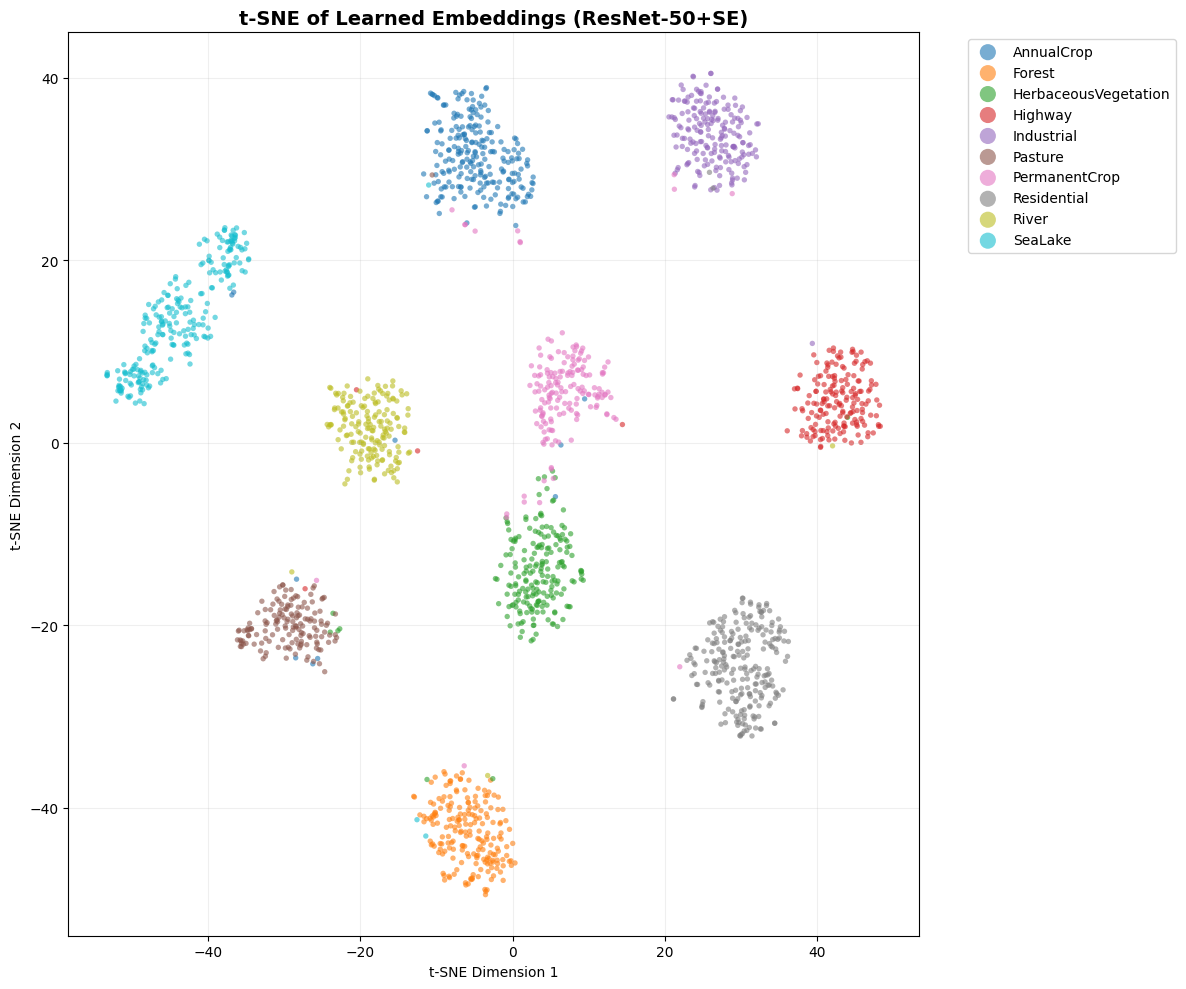

In [8]:
fig, ax = plt.subplots(figsize=(12, 10))
scatter_colors = plt.cm.tab10(np.linspace(0, 1, 10))

for cls_idx in range(len(CLASS_NAMES)):
    mask = embed_labels == cls_idx
    ax.scatter(embeds_2d[mask, 0], embeds_2d[mask, 1],
               c=[scatter_colors[cls_idx]], label=CLASS_NAMES[cls_idx],
               alpha=0.6, s=15, edgecolors='none')

ax.legend(fontsize=10, bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=3)
ax.set_title('t-SNE of Learned Embeddings (ResNet-50+SE)', fontsize=14, fontweight='bold')
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'tsne_embeddings.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. UMAP Embedding Visualization

UMAP (Uniform Manifold Approximation and Projection) - better at preserving global structure than t-SNE.

Running UMAP...


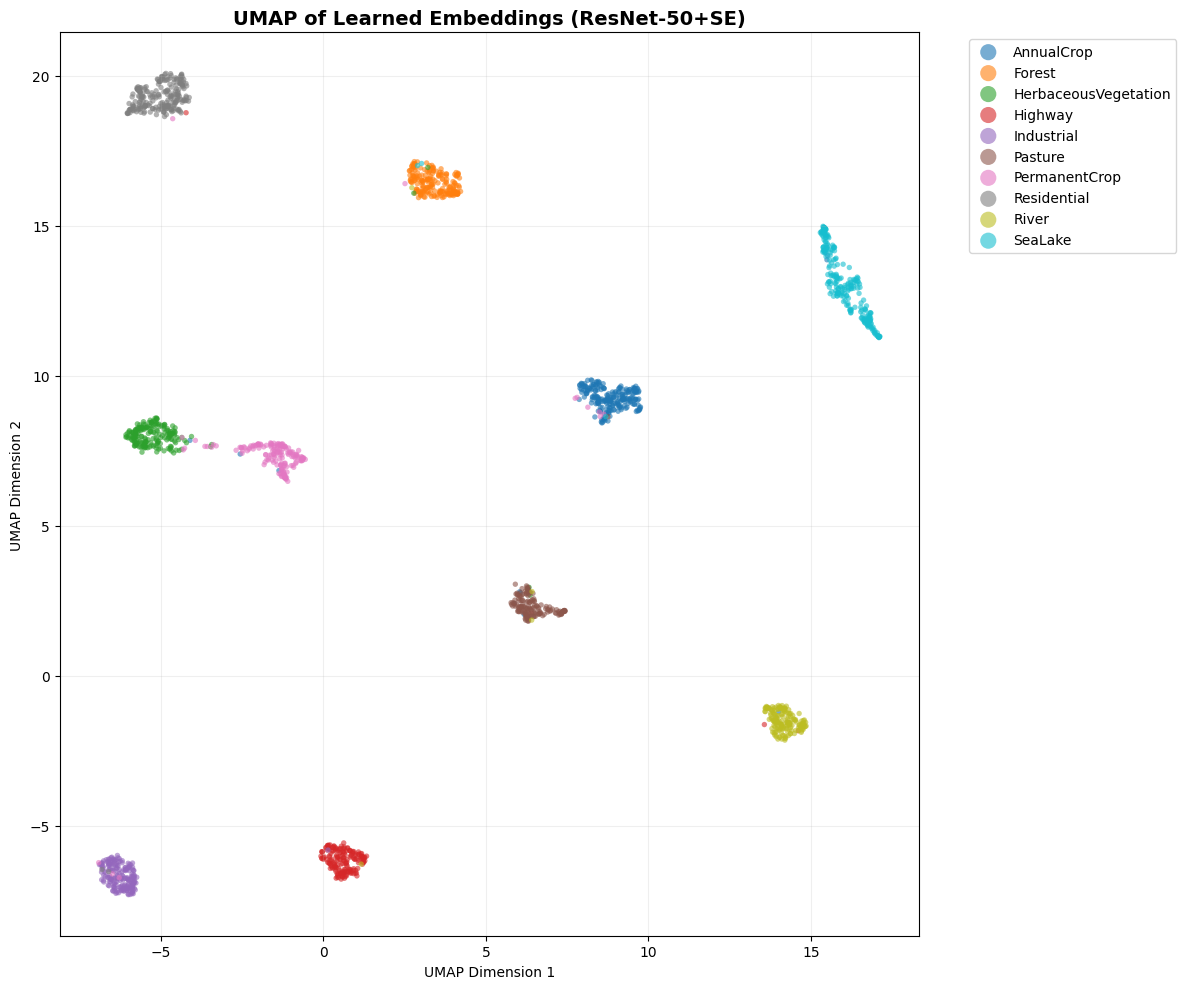

In [9]:
try:
    import umap

    print("Running UMAP...")
    reducer = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=15, min_dist=0.1)
    embeds_umap = reducer.fit_transform(embeds)

    fig, ax = plt.subplots(figsize=(12, 10))
    for cls_idx in range(len(CLASS_NAMES)):
        mask = embed_labels == cls_idx
        ax.scatter(embeds_umap[mask, 0], embeds_umap[mask, 1],
                   c=[scatter_colors[cls_idx]], label=CLASS_NAMES[cls_idx],
                   alpha=0.6, s=15, edgecolors='none')

    ax.legend(fontsize=10, bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=3)
    ax.set_title('UMAP of Learned Embeddings (ResNet-50+SE)', fontsize=14, fontweight='bold')
    ax.set_xlabel('UMAP Dimension 1')
    ax.set_ylabel('UMAP Dimension 2')
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'umap_embeddings.png'), dpi=150, bbox_inches='tight')
    plt.show()
except ImportError:
    print("umap-learn not installed. Run: pip install umap-learn")

## Summary

Generated interpretability visualizations:
- **Grad-CAM**: Shows the model focuses on relevant spatial features (vegetation patches for crops, road lines for highway, water bodies for river/sea)
- **t-SNE**: Clusters show how well the model separates classes in its learned representation
- **UMAP**: Alternative to t-SNE, better global structure preservation

**Figures saved to:** `experiments/results/figures/`

**Next:** Run `06_Robustness_Quantization.ipynb` locally.